<a href="https://colab.research.google.com/github/lonehuntress/set_of_titanic/blob/main/train_dataset_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd

# Load the training data into a pandas DataFrame
df = pd.read_csv('train.csv')

# Display the first 5 rows of the DataFrame
display(df.head())
y = df['Survived']
X = df.drop('Survived', axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [24]:
chriffre = list()
lettre = list()
# from numpy import int64 # This import is not needed for this logic
for i in X.columns :
  if X[i].dtype == "int64" or X[i].dtype == "float64" :
    chriffre.append(i)
  elif X[i].dtype == "object" :
    lettre.append(i)
print(chriffre)
print(lettre)

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [27]:
chriffre_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
lettre_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [28]:
transformer = ColumnTransformer(transformers=[
    ('chriffre', chriffre_transformer, chriffre),
    ('lettre', lettre_transformer, lettre)
])

In [30]:
from sklearn.linear_model import LogisticRegression

Maintenant, nous allons créer un pipeline complet qui combine notre `ColumnTransformer` de prétraitement et un modèle de `LogisticRegression`.

In [39]:
model_pipeline = Pipeline(steps=[
    ('processing',  transformer),
    ('classification',  LogisticRegression())
])

Nous allons diviser les données en ensembles d'entraînement et de test pour évaluer les performances du modèle sur des données non vues.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Entraînons maintenant le pipeline sur les données d'entraînement.

In [41]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('processing',
                 ColumnTransformer(transformers=[('chriffre',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('lettre',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked'])])),
                ('classification', LogisticRegression())])

Enfin, évaluons la précision du modèle sur l'ensemble de test.

In [42]:
accuracy = model_pipeline.score(X_test, y_test)
print(f"Précision du modèle : {accuracy:.4f}")

Précision du modèle : 0.8492


In [43]:
from sklearn.ensemble import RandomForestClassifier

Créons un nouveau pipeline avec un `RandomForestClassifier`.

In [46]:
rf_model_pipeline = Pipeline(steps=[
    ('preprocessor', transformer),
    ('classifier', RandomForestClassifier(random_state=0))
])

Entraînons le modèle Random Forest sur les données d'entraînement.

In [47]:
rf_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('chriffre',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('lettre',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked'])])),
                ('classifier', RandomForestClassifier(random_state=0))])

Évaluons la précision du modèle Random Forest sur l'ensemble de test.

In [48]:
rf_accuracy = rf_model_pipeline.score(X_test, y_test)
print(f"Précision du modèle Random Forest : {rf_accuracy:.4f}")
print(f"Précision du modèle Logistic Regression : {accuracy:.4f}")

Précision du modèle Random Forest : 0.8436
Précision du modèle Logistic Regression : 0.8492


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Matrice de Confusion pour la Régression Logistique

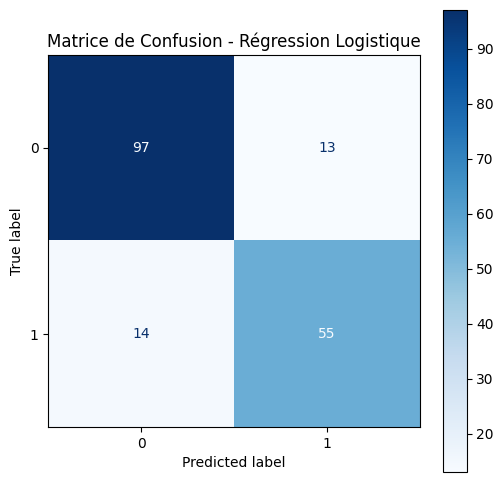

In [50]:
y_pred_lr = model_pipeline.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig_lr, ax_lr = plt.subplots(figsize=(6, 6))
display_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=model_pipeline.classes_)
display_lr.plot(cmap=plt.cm.Blues, ax=ax_lr)
ax_lr.set_title('Matrice de Confusion - Régression Logistique')
plt.show()

### Matrice de Confusion pour Random Forest

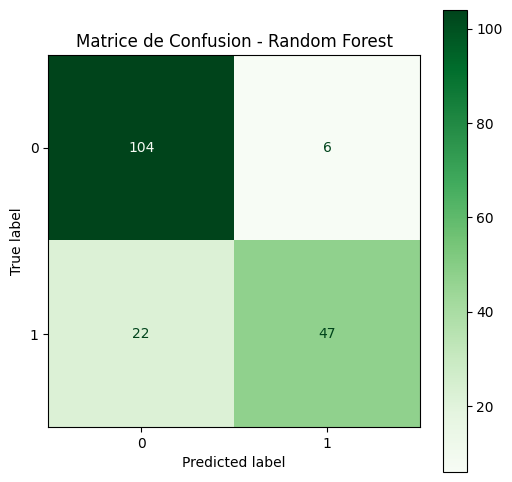

In [51]:
y_pred_rf = rf_model_pipeline.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig_rf, ax_rf = plt.subplots(figsize=(6, 6))
display_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model_pipeline.classes_)
display_rf.plot(cmap=plt.cm.Greens, ax=ax_rf)
ax_rf.set_title('Matrice de Confusion - Random Forest')
plt.show()

### Classification Report for Logistic Regression

In [52]:
from sklearn.metrics import classification_report

y_pred_lr = model_pipeline.predict(X_test)
print("Classification Report - Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr, target_names=['Not Survived', 'Survived']))

Classification Report - Logistic Regression:

              precision    recall  f1-score   support

Not Survived       0.87      0.88      0.88       110
    Survived       0.81      0.80      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



### Classification Report for Random Forest

In [53]:
from sklearn.metrics import classification_report

y_pred_rf = rf_model_pipeline.predict(X_test)
print("Classification Report - Random Forest:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Not Survived', 'Survived']))

Classification Report - Random Forest:

              precision    recall  f1-score   support

Not Survived       0.83      0.95      0.88       110
    Survived       0.89      0.68      0.77        69

    accuracy                           0.84       179
   macro avg       0.86      0.81      0.83       179
weighted avg       0.85      0.84      0.84       179



### Explication du Rapport de Classification

Le rapport de classification fournit un résumé détaillé des performances du modèle, incluant les métriques suivantes pour chaque classe (0: Non Survie, 1: Survie) :

*   **Precision (Précision)** : La proportion d'identifications positives qui étaient réellement correctes. C'est `Vrai Positifs / (Vrai Positifs + Faux Positifs)`.
*   **Recall (Rappel / Sensibilité)** : La proportion de positifs réels qui ont été correctement identifiés. C'est `Vrai Positifs / (Vrai Positifs + Faux Négatifs)`.
*   **F1-Score** : La moyenne harmonique pondérée de la précision et du rappel. C'est un bon indicateur de l'exactitude du modèle, en particulier si vous avez un déséquilibre de classes. Il est calculé comme `2 * (Precision * Recall) / (Precision + Recall)`.
*   **Support** : Le nombre d'occurrences réelles de la classe dans l'ensemble de données spécifié.

Le rapport inclut également des moyennes globales :

*   **Accuracy (Exactitude)** : La proportion d'observations correctement classées. C'est `(Vrai Positifs + Vrai Négatifs) / Total d'observations`.
*   **Macro Avg (Moyenne Macro)** : La moyenne non pondérée de la précision, du rappel et du score F1 par classe. Toutes les classes sont traitées de manière égale.
*   **Weighted Avg (Moyenne Pondérée)** : La moyenne de la précision, du rappel et du score F1 par classe, pondérée par le `support` de chaque classe. Cela tient compte du déséquilibre des classes.

### Optimisation du Modèle Random Forest avec GridSearchCV

Nous allons maintenant utiliser `GridSearchCV` pour trouver les meilleurs hyperparamètres pour notre `RandomForestClassifier`. Cela permettra d'améliorer potentiellement les performances du modèle en explorant différentes combinaisons de paramètres.

In [54]:
from sklearn.model_selection import GridSearchCV

# Définir la grille de paramètres à explorer
param_grid = {
    'classifier__n_estimators': [100, 200, 300],  # Nombre d'arbres dans la forêt
    'classifier__max_depth': [None, 10, 20],  # Profondeur maximale de chaque arbre
    'classifier__min_samples_split': [2, 5],  # Nombre minimum d'échantillons requis pour diviser un nœud interne
    'classifier__min_samples_leaf': [1, 2]  # Nombre minimum d'échantillons requis à chaque feuille
}

# Initialiser GridSearchCV
# 'rf_model_pipeline' est notre pipeline qui inclut le preprocessor et le RandomForestClassifier
# 'scoring' définit la métrique à optimiser (ici, la précision)
# 'cv' est le nombre de plis pour la validation croisée
# 'n_jobs=-1' utilise tous les cœurs de processeur disponibles pour accélérer le calcul
grid_search_rf = GridSearchCV(estimator=rf_model_pipeline,
                            param_grid=param_grid,
                            scoring='accuracy',
                            cv=5,
                            n_jobs=-1,
                            verbose=1)

# Exécuter la recherche sur grille sur les données d'entraînement
print("Début de la recherche sur grille pour Random Forest...")
grid_search_rf.fit(X_train, y_train)
print("Recherche sur grille terminée.")

Début de la recherche sur grille pour Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Recherche sur grille terminée.


### Meilleurs Hyperparamètres et Score du Modèle Optimisé

Après la recherche sur grille, nous pouvons examiner les meilleurs paramètres trouvés et le score de précision obtenu par le modèle `RandomForestClassifier` avec ces paramètres.

In [55]:
# Afficher les meilleurs paramètres trouvés
print(f"Meilleurs paramètres trouvés : {grid_search_rf.best_params_}")

# Afficher le meilleur score (précision moyenne de la validation croisée)
print(f"Meilleur score de précision (validation croisée) : {grid_search_rf.best_score_:.4f}")

# Obtenir le meilleur estimateur (le pipeline avec les meilleurs paramètres)
best_rf_model = grid_search_rf.best_estimator_

# Évaluer la précision du modèle optimisé sur l'ensemble de test
best_rf_accuracy = best_rf_model.score(X_test, y_test)
print(f"Précision du modèle Random Forest optimisé sur l'ensemble de test : {best_rf_accuracy:.4f}")

Meilleurs paramètres trouvés : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Meilleur score de précision (validation croisée) : 0.8160
Précision du modèle Random Forest optimisé sur l'ensemble de test : 0.8324


### Optimisation du Modèle de Régression Logistique avec GridSearchCV

Nous allons maintenant appliquer `GridSearchCV` au modèle de `LogisticRegression` pour rechercher une meilleure combinaison d'hyperparamètres.

In [56]:
from sklearn.model_selection import GridSearchCV

# Définir la grille de paramètres pour la Régression Logistique
# 'model_pipeline' a le nom 'classification' pour l'étape du classifieur
param_grid_lr = {
    'classification__C': [0.001, 0.01, 0.1, 1, 10, 100], # Inverse de la force de régularisation; plus petit = plus forte régularisation
    'classification__solver': ['liblinear', 'saga'], # Algorithme à utiliser dans le problème d'optimisation
    'classification__penalty': ['l1', 'l2'] # Spécifie la norme utilisée dans la pénalisation
}

# Initialiser GridSearchCV pour le pipeline de Régression Logistique
grid_search_lr = GridSearchCV(estimator=model_pipeline,
                            param_grid=param_grid_lr,
                            scoring='accuracy',
                            cv=5,
                            n_jobs=-1,
                            verbose=1)

# Exécuter la recherche sur grille
print("Début de la recherche sur grille pour la Régression Logistique...")
grid_search_lr.fit(X_train, y_train)
print("Recherche sur grille terminée.")

Début de la recherche sur grille pour la Régression Logistique...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Recherche sur grille terminée.


### Meilleurs Hyperparamètres et Score du Modèle de Régression Logistique Optimisé

Analysons les résultats de la recherche sur grille pour la régression logistique.

In [57]:
# Afficher les meilleurs paramètres trouvés
print(f"Meilleurs paramètres trouvés (Régression Logistique) : {grid_search_lr.best_params_}")

# Afficher le meilleur score (précision moyenne de la validation croisée)
print(f"Meilleur score de précision (validation croisée) : {grid_search_lr.best_score_:.4f}")

# Obtenir le meilleur estimateur
best_lr_model = grid_search_lr.best_estimator_

# Évaluer la précision du modèle optimisé sur l'ensemble de test
best_lr_accuracy = best_lr_model.score(X_test, y_test)
print(f"Précision du modèle de Régression Logistique optimisé sur l'ensemble de test : {best_lr_accuracy:.4f}")

Meilleurs paramètres trouvés (Régression Logistique) : {'classification__C': 100, 'classification__penalty': 'l2', 'classification__solver': 'liblinear'}
Meilleur score de précision (validation croisée) : 0.8160
Précision du modèle de Régression Logistique optimisé sur l'ensemble de test : 0.8492
